# ML Lab 11
## Name - Manan Chahal
## Roll No - 23102C0044

## Imports and preprocessing

In [2]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import sklearn

import pandas as pd
import numpy as np

In [3]:
data = fetch_20newsgroups()


print(type(data))


<class 'sklearn.utils._bunch.Bunch'>


In [4]:
df = pd.DataFrame()

df['text'] = data.get('data')
df['type'] = data.get('target')

df.head()

,text,type
0,From: lerxst@wam.umd.edu (where's my thing)\nS...,7
1,From: guykuo@carson.u.washington.edu (Guy Kuo)...,4
2,From: twillis@ec.ecn.purdue.edu (Thomas E Will...,4
3,From: jgreen@amber (Joe Green)\nSubject: Re: W...,1
4,From: jcm@head-cfa.harvard.edu (Jonathan McDow...,14


In [5]:
print(df.shape)

print(df['text'][0])

(11314, 2)
From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

Thanks,
- IL
   ---- brought to you by your neighborhood Lerxst ----







In [6]:
vectorizer = TfidfVectorizer(
    max_df=0.95,
    min_df=2,
    stop_words='english'
)

X_tfidf = vectorizer.fit_transform(df['text'])

print(X_tfidf.shape)

(11314, 56123)


# Applying SVD at various component sizes

In [7]:
components_list = [50, 100, 200]

svd_models = {}
X_reduced_dict = {}

for n in components_list:
    svd = TruncatedSVD(n_components=n, random_state=42)
    X_reduced = svd.fit_transform(X_tfidf)
    
    svd_models[n] = svd
    X_reduced_dict[n] = X_reduced
    
    print(f"Components: {n}, Explained Variance: {svd.explained_variance_ratio_.sum():.4f}")

Components: 50, Explained Variance: 0.0759
Components: 100, Explained Variance: 0.1185
Components: 200, Explained Variance: 0.1819


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for n in components_list:
    X_reduced = X_reduced_dict[n]
    
    kmeans = KMeans(n_clusters=len(df['type'].unique()), random_state=42)
    labels = kmeans.fit_predict(X_reduced)
    
    score = silhouette_score(X_reduced, labels)
    
    results.append((n, score))
    
    print(f"Components: {n}, Silhouette Score: {score:.4f}")

Components: 50, Silhouette Score: 0.0785
Components: 100, Silhouette Score: 0.0684
Components: 200, Silhouette Score: 0.0498


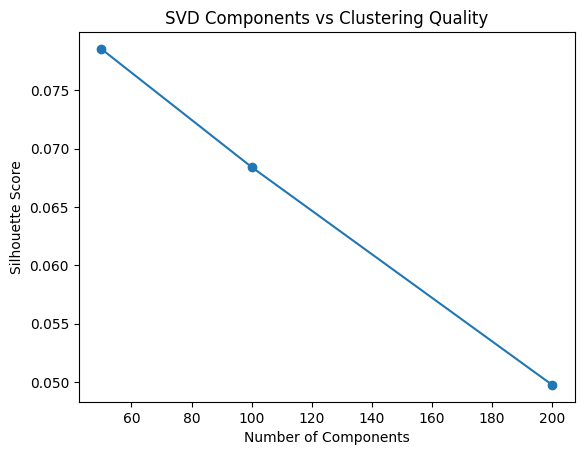

In [9]:
import matplotlib.pyplot as plt

components = [r[0] for r in results]
scores = [r[1] for r in results]

plt.plot(components, scores, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.title("SVD Components vs Clustering Quality")
plt.show()

The silhouette score decreases as the number of SVD components increases. 
This suggests that lower-dimensional representations capture more meaningful 
latent structure, while higher dimensions introduce noise and reduce cluster separability.

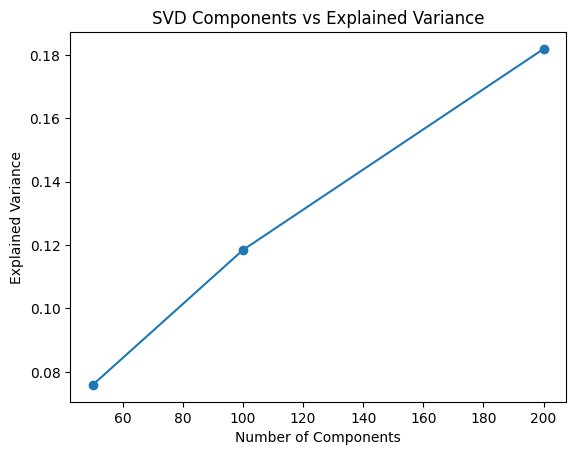

In [10]:
variance_scores = []

for n in components_list:
    var = svd_models[n].explained_variance_ratio_.sum()
    variance_scores.append(var)

import matplotlib.pyplot as plt

plt.plot(components_list, variance_scores, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.title("SVD Components vs Explained Variance")
plt.show()

In [11]:
def print_topics(model, vectorizer, n_terms=10, n_topics=5):
    terms = vectorizer.get_feature_names_out()
    
    topics_output = []
    
    for i, comp in enumerate(model.components_[:n_topics]):
        term_indices = comp.argsort()[-n_terms:][::-1]
        topic_terms = [terms[j] for j in term_indices]
        
        topic_str = f"Topic {i}: " + ", ".join(topic_terms)
        print(topic_str)
        topics_output.append(topic_str)
    
    return topics_output

In [12]:
topics = print_topics(svd_models[100], vectorizer)

Topic 0: edu, com, writes, article, people, don, just, like, university, know
Topic 1: god, people, jesus, bible, christian, believe, christians, faith, say, christ
Topic 2: edu, cs, pitt, university, geb, gordon, banks, cc, cwru, game
Topic 3: god, windows, scsi, jesus, drive, dos, card, bible, christian, christians
Topic 4: geb, pitt, banks, gordon, cs, god, edu, key, cadre, n3jxp


# Training a classifer on the data

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

accuracy_scores = []
for n in components_list:
    X_reduced = X_reduced_dict[n]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_reduced, df['type'], test_size=0.2, random_state=42
    )
    
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)

    accuracy_scores.append(acc)
    
    print(f"Components: {n}, Accuracy: {acc:.4f}")

Components: 50, Accuracy: 0.7552
Components: 100, Accuracy: 0.7989
Components: 200, Accuracy: 0.8405


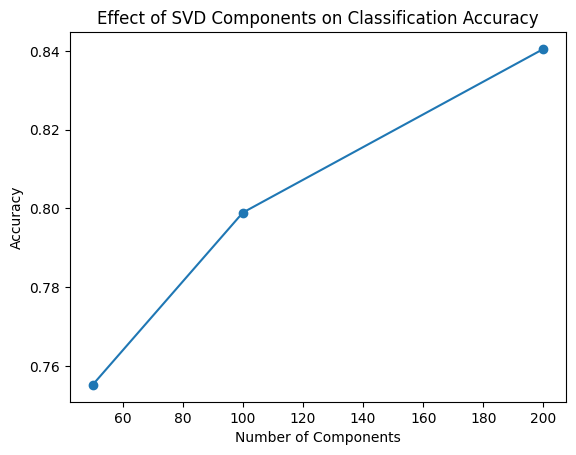

In [16]:
plt.plot(components_list, accuracy_scores, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Accuracy")
plt.title("Effect of SVD Components on Classification Accuracy")
plt.show()

Latent Semantic Analysis (LSA) using Truncated SVD is an effective technique for reducing the dimensionality of sparse text data while preserving its underlying semantic structure. In this experiment, TF-IDF vectorization was applied to convert text into numerical form, followed by SVD to extract lower-dimensional representations. The results show that as the number of components increases, more variance from the original data is retained, which improves classification accuracy. This indicates that supervised models benefit from richer feature representations. However, the clustering performance, measured using the silhouette score, decreases with an increase in components.

This happens because higher dimensions introduce noise and reduce the separability of clusters. On the other hand, lower-dimensional representations capture only the most dominant patterns, leading to better cluster formation. These observations highlight that the optimal number of components depends on the specific task. Fewer components are more suitable for clustering, while a larger number of components improves classification performance. Thus, SVD plays a crucial role in balancing dimensionality reduction and information retention in text mining applications.